In [1]:
from torch.utils.data import DataLoader
from utils import OCTMendeleyDataset, plotimg, LitSupervised, OCTRandAugment, TransferLearning, CONFIG
import torch
from torch import nn
from torchvision.models import (
    resnet152,
    resnet50,
    densenet169,
    efficientnet_b0,
    mobilenet_v2,
    mobilenet_v3_large,
    mobilenet_v3_small,
)
from torchvision.transforms import v2
import lightning as L
from torchinfo import summary

In [2]:
train_dataset = OCTMendeleyDataset("train")
validation_dataset = OCTMendeleyDataset("validation")
test_dataset = OCTMendeleyDataset("test")

In [3]:
OCTMendeleyDataset.classes()

['NORMAL', 'CNV', 'DME', 'DRUSEN']

In [4]:
_index = 6
path, _ = test_dataset.path_instance_pair(_index)
instance, label = test_dataset[_index]

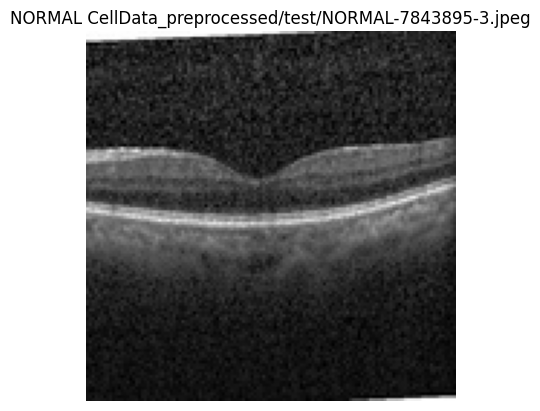

In [5]:
plotimg(instance, f"{OCTMendeleyDataset.classes()[label]} {path}")

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"])
validation_loader = DataLoader(validation_dataset, batch_size=CONFIG["batch_size"])

In [7]:
TransferLearning.models = {
    "resnet152": resnet152(),
    "resnet50": resnet50(),
    "densenet169": densenet169(),
    #"efficientnet_b0": efficientnet_b0(),
    #"mobilenet_v2": mobilenet_v2(),
    #"mobilenet_v3_large": mobilenet_v3_large(),
    #"mobilenet_v3_small": mobilenet_v3_small(),
}

In [8]:
size = instance.size
summary(TransferLearning.models["resnet152"], input_size=(CONFIG["batch_size"],size(0),size(1),size(2)), depth = 1)

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [80, 1000]                --
├─Conv2d: 1-1                            [80, 64, 64, 64]          9,408
├─BatchNorm2d: 1-2                       [80, 64, 64, 64]          128
├─ReLU: 1-3                              [80, 64, 64, 64]          --
├─MaxPool2d: 1-4                         [80, 64, 32, 32]          --
├─Sequential: 1-5                        [80, 256, 32, 32]         215,808
├─Sequential: 1-6                        [80, 512, 16, 16]         2,339,840
├─Sequential: 1-7                        [80, 1024, 8, 8]          40,613,888
├─Sequential: 1-8                        [80, 2048, 4, 4]          14,964,736
├─AdaptiveAvgPool2d: 1-9                 [80, 2048, 1, 1]          --
├─Linear: 1-10                           [80, 1000]                2,049,000
Total params: 60,192,808
Trainable params: 60,192,808
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 300

In [9]:
TransferLearning.replace_head("resnet152", len(OCTMendeleyDataset.classes()))

In [10]:
# Freeze weights
TransferLearning.set_grads("resnet152")

conv1.weight None False
bn1.weight None False
bn1.bias None False
layer1.0.conv1.weight None False
layer1.0.bn1.weight None False
layer1.0.bn1.bias None False
layer1.0.conv2.weight None False
layer1.0.bn2.weight None False
layer1.0.bn2.bias None False
layer1.0.conv3.weight None False
layer1.0.bn3.weight None False
layer1.0.bn3.bias None False
layer1.0.downsample.0.weight None False
layer1.0.downsample.1.weight None False
layer1.0.downsample.1.bias None False
layer1.1.conv1.weight None False
layer1.1.bn1.weight None False
layer1.1.bn1.bias None False
layer1.1.conv2.weight None False
layer1.1.bn2.weight None False
layer1.1.bn2.bias None False
layer1.1.conv3.weight None False
layer1.1.bn3.weight None False
layer1.1.bn3.bias None False
layer1.2.conv1.weight None False
layer1.2.bn1.weight None False
layer1.2.bn1.bias None False
layer1.2.conv2.weight None False
layer1.2.bn2.weight None False
layer1.2.bn2.bias None False
layer1.2.conv3.weight None False
layer1.2.bn3.weight None False
layer1.2

In [11]:
litmodel = LitSupervised(TransferLearning.models["resnet152"])

In [12]:
trainer = L.Trainer(accelerator="gpu", max_epochs=10)
trainer.fit(model=litmodel, train_dataloaders=train_loader, val_dataloaders=validation_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type   | Params | Mode 
-----------------------------------------
0 | model | ResNet | 58.2 M | train
-----------------------------------------
8.2 K     Trainable params
58.1 M    Non-trainable params
58.2 M    Total params
232.608   Total estimated model params size (MB)
423       Modules in train mode
0         Modules in eval mode


Sanity Checking DataLoader 0:  50%|█████     | 1/2 [00:00<00:00, 14.53it/s]

/home/polyester/Desktop/Programming/OCT-Project/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


/home/polyester/Desktop/Programming/OCT-Project/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Epoch 0:  98%|█████████▊| 338/345 [01:09<00:01,  4.84it/s, v_num=0, Train Loss=1.430, Train Accuracy=0.300]


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/home/polyester/Desktop/Programming/OCT-Project/.venv/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
